In [1]:
# Start with an example to visualize Central Limit Theorem
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [2]:
# ---------------------------------------------------------
# 1. Create a highly skewed population (exponential)
# 
# The exponential distribution is very right-skewed, which is perfect for demonstrating the CLT
# because it is NOT normal.  It looks like this:
# * Many small values near 0
# * A long tail of larger values
# * Mean = scale
# * Variance = scale^2 (the standard deviation is also 1)
# The point of using this distribution is to show that even if the population is NOT NORMAL, the distribution
# of the sample means becomes normal as n increases
# When you sample means of size:
#
# n = 5 → still skewed
#
# n = 30 → more symmetric
#
# n = 100 → almost perfectly normal
#
# That transformation is the CLT in action.
# ---------------------------------------------------------
population = np.random.exponential(scale=1, size=1_000_000)

# Population parameters
mu = population.mean()
sigma = population.std()

In [3]:
# ---------------------------------------------------------
# 2. Function to generate sampling distribution of means
# 
# Returns a array of sample means. It randomly selects n values
# from the population and calculates the mean of that sample. 
# It performs this reps amount of times and returns the array of means
# ---------------------------------------------------------
def sample_means(n, reps=10000):
    means = []
    for _ in range(reps):
        sample = np.random.choice(population, size=n, replace=True)
        means.append(sample.mean())
    return np.array(means)

In [4]:
# Sample sizes to demonstrate CLT
ns = [5, 30, 100]

In [5]:
# Generate sampling distributions
means_5 = sample_means(5)
means_30 = sample_means(30)
means_100 = sample_means(100)

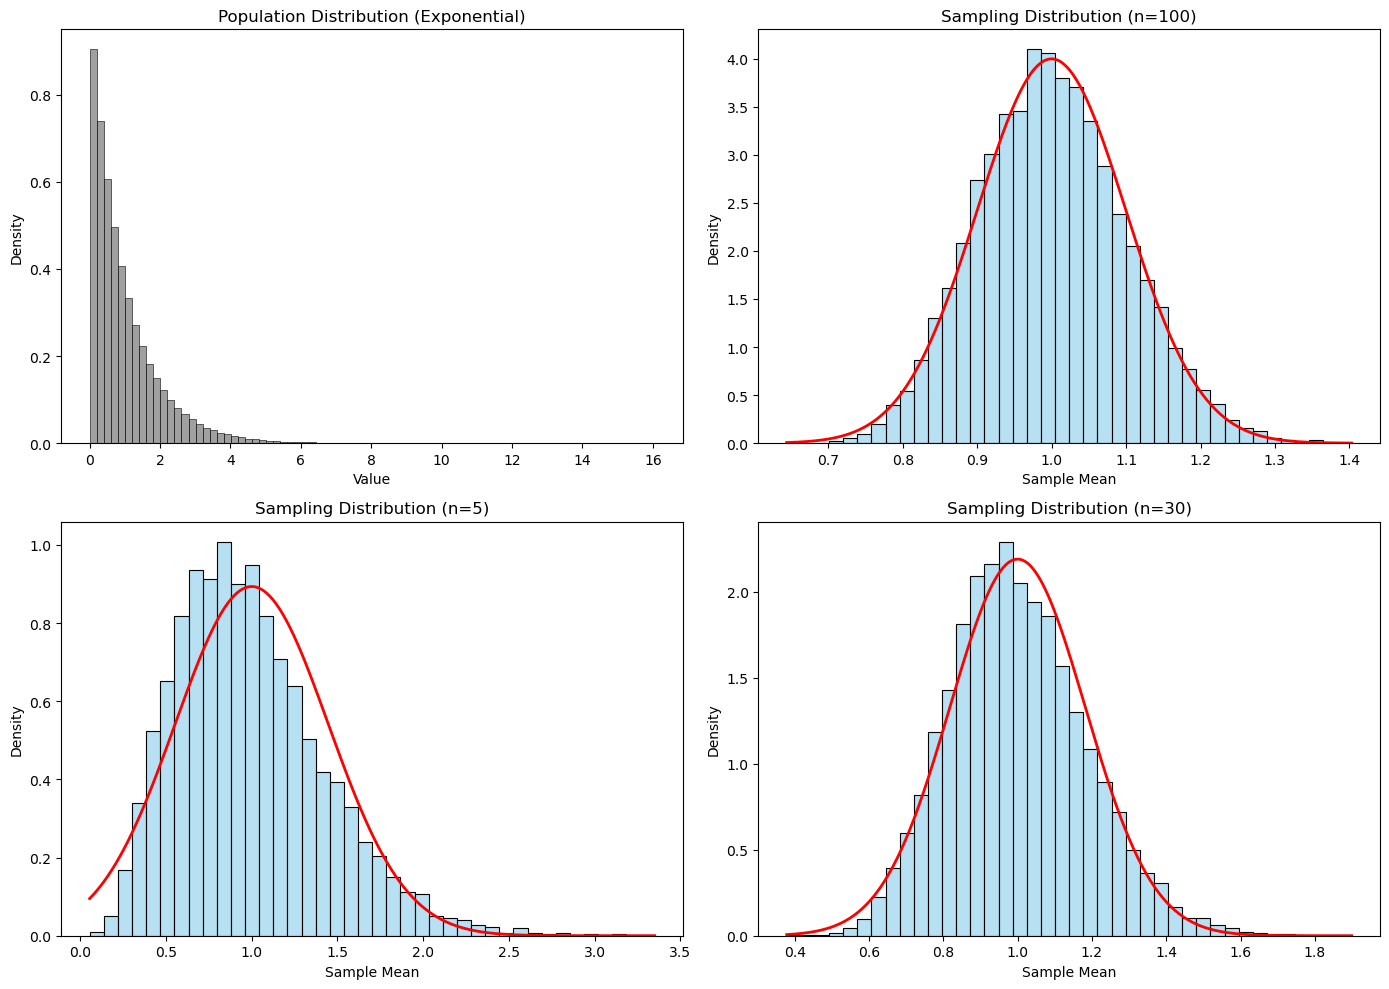

In [6]:
# ---------------------------------------------------------
# 3. Plot everything
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Population distribution ---
sns.histplot(population, bins=80, stat="density", color="gray", ax=axes[0,0])
axes[0,0].set_title("Population Distribution (Exponential)")
axes[0,0].set_xlabel("Value")
axes[0,0].set_ylabel("Density")
# Helper to plot sampling distributions + normal overlay
def plot_sampling(ax, data, n):
    sns.histplot(data, bins=40, stat="density", color="skyblue", alpha=0.6, ax=ax)

    # Theoretical normal curve
    se = sigma / np.sqrt(n)
    x = np.linspace(data.min(), data.max(), 400)
    y = norm.pdf(x, loc=mu, scale=se)
    ax.plot(x, y, color="red", linewidth=2)

    ax.set_title(f"Sampling Distribution (n={n})")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Density")

# --- Sampling distributions ---
plot_sampling(axes[1,0], means_5, 5)
plot_sampling(axes[1,1], means_30, 30)
plot_sampling(axes[0,1], means_100, 100)

plt.tight_layout()
plt.show()

### What do you see?

#### Top-left:
A very skewed exponential population — clearly not normal.

#### Bottom-left (n = 5):
Still skewed, but already more symmetric than the population.

#### Bottom-right (n = 30):
Much more bell‑shaped. The red normal curve fits well.

#### Top-right (n = 100):
Almost perfectly normal.
The theoretical curve overlays beautifully.

This is the **Central Limit Theorem** unfolding visually.